In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba, MambaConfig
import mamba_model
import argparse
from DataProcessing import HankelMatrices,HankelMatricesStates,  HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates, Sequence2SequenceFuture, Sequence2SequencePast
import scipy.io
import scipy.io
from torch.utils.data import DataLoader, TensorDataset


In [2]:
# Load multisine data from matlab
filename  = "ChirpWhiteNoise" 
mat = scipy.io.loadmat("DataSets/u_data"+filename+".mat")
u_data = mat["u_data"]

mat = scipy.io.loadmat("DataSets/y_data"+filename+".mat")
y_data = mat["y_data"]

# convert data to tensors
u_data = np.array(u_data)
y_data = np.array(y_data)

u_data = torch.FloatTensor(u_data).transpose(0,1)
#u_data = u_data[0,:1000].unsqueeze(0).transpose(0,1)
y_data = torch.FloatTensor(y_data).transpose(0,1)
#y_data = y_data[0,:1000].unsqueeze(0).transpose(0,1)
#y_data = y_data[0,:].unsqueeze(1)
#torch.reshape(y_data,(1000, 1))
input_dim = list(u_data.shape)[1]
output_dim = list(y_data.shape)[1]

# Hyper parameters
T_ini = 3
T = y_data.shape[0]
N =10
L = 20
DataShuffle = False
norm_data = True


# u_data_train = u_data[0:round(0.8*T)]
# y_data_train = y_data[0:round(0.8*T)]
# U_ini, Y_ini,U_0_Nm1, Y_1_N = HankelMatrices(u_data_train,y_data_train,T_ini,N,round(0.8*T) , input_dim, output_dim )

# trainX= torch.cat((U_ini, Y_ini, U_0_Nm1), 1)
# trainy = Y_1_N




u_data_test = u_data
y_data_test = y_data
U_ini, Y_ini,U_0_Nm1, Y_1_N = HankelMatrices(u_data_test,y_data_test,T_ini,N,round(T) , input_dim, output_dim )
# testX, testy = HankelMatricesSequences(U_ini, Y_ini,U_0_Nm1, Y_1_N, L)

# testX = Sequence2Sequence(U_ini, Y_ini, U_0_Nm1)
# testX = torch.cat((U_ini, Y_ini, U_0_Nm1), 1).unsqueeze(1).transpose(1,2)
# testY = Y_1_N.unsqueeze(2)

testX, testY  = Sequence2Sequence(U_ini, Y_ini, U_0_Nm1, Y_1_N)
# testX, testY  = Sequence2SequencePast(U_ini, Y_ini, U_0_Nm1, Y_1_N)
# testX,testY = Sequence2SequenceFuture(U_ini, Y_ini,U_0_Nm1,Y_1_N)


# mat = scipy.io.loadmat("DataSets/X0_val.mat")
# X0_val = mat["X0_val"]

# mat = scipy.io.loadmat("DataSets/Y_val.mat")
# Y_val = mat["Y_val"]

# mat = scipy.io.loadmat("DataSets/U_val.mat")
# U_val = mat["U_val"]

# X0_val = torch.FloatTensor(np.array(X0_val))
# Y_val = torch.FloatTensor(np.array(Y_val))
# U_val = torch.FloatTensor(np.array(U_val))


# testX,testY = Sequence2SequenceStates(X0_val,U_val,Y_val)

Hankel Matrices Generated


In [3]:
np.repeat([0, 1, 0, 0, 0], 40).shape

(200,)

In [2]:
filename = "Mix"
mat = scipy.io.loadmat("DataSets/x_data"+filename+".mat")
x_data = mat["x"]
x_data = torch.FloatTensor(x_data).transpose(0,1)

mat = scipy.io.loadmat("DataSets/u_data"+filename+".mat")
u_data = mat["u_data"]
u_data = torch.FloatTensor(u_data).transpose(0,1)


U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_data,x_data, 10)
testX,testY = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)

Hankel Matrices Generated


NameError: name 'y_data' is not defined

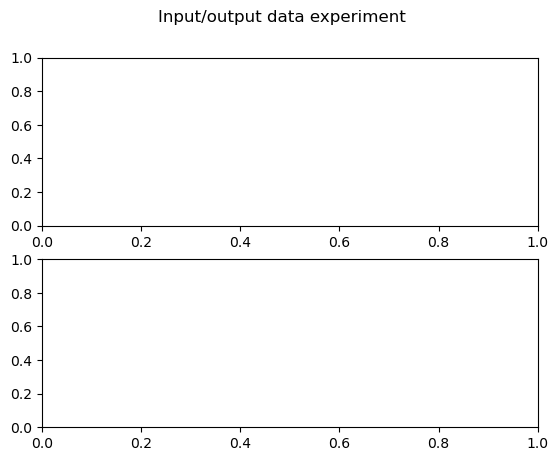

In [3]:
# Plot the pendulum trajectory together with the input
fig, axs = plt.subplots(2)
fig.suptitle("Input/output data experiment")
axs[0].plot(y_data[:,])
#axs[1].plot(y_data[:,1])
axs[1].plot(u_data)
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="u")
plt.show()

plt.savefig('destination_path.eps', format='eps')

In [3]:
   
class NetSequences(nn.Module):
    def __init__(self,in_dim,out_dim,L):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 4, d_state = 8)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)
        return x.squeeze(0) 

In [41]:
model = NetSequences(3,2,1)
model.load_state_dict(torch.load("State_dicts/ZOH_D8_dstate8_Conv4_ThomasLarge_N10")['model_state_dict'])


<All keys matched successfully>

In [42]:
model.eval()
mat = model(testX)
yhat = mat.detach().numpy()

In [43]:
testY.shape

torch.Size([39991, 10, 2])

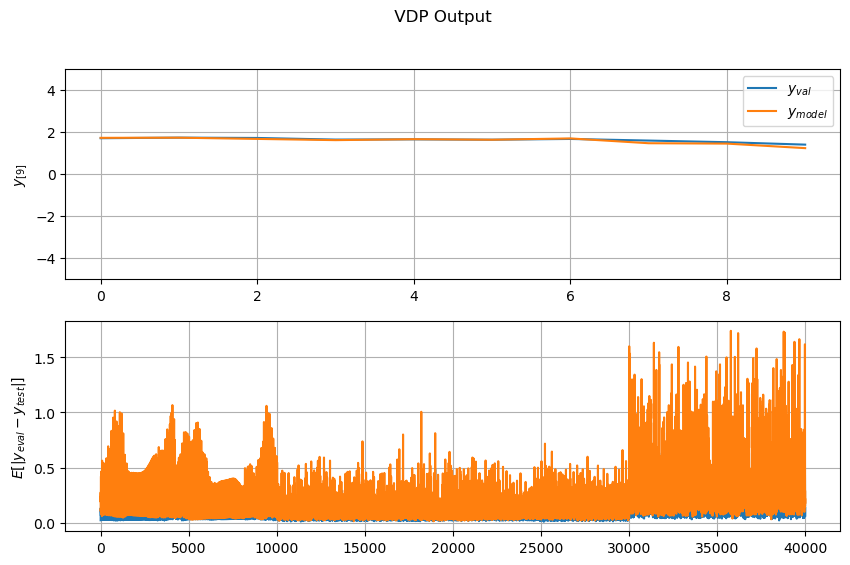

In [44]:
MAE = np.mean(np.abs(yhat - testY.numpy()),1)
RMAE = np.sqrt(MAE)
NRMAE = RMAE/(np.max(testY.numpy())-np.min(testY.numpy()))

N_step  = 1
Index  = 100

fig, axs = plt.subplots(2, figsize=(10, 6))
fig.suptitle(" VDP Output")
axs[0].plot(testY[Index,:,0], label="$y_{val}$")
axs[0].plot(yhat[Index,:,0], label = "$y_{model}$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-5, 5)

axs[1].plot(MAE)
axs[0].set(ylabel="$y_{[9]}$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$E[|y_{eval}-y_{test}|]$")
axs[1].grid()
plt.show()
fig.savefig("MambaValidationSet"+filename+".png", format='png', dpi=300)

In [45]:
TotalError = np.sum(MAE)
print("Total Error:"+str(TotalError))

Total Error:11706.005


In [46]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Calculate R-squared
r2_x1 = r2_score(testY[:,:,0].numpy(), yhat[:,:,0] )
r2_x2 = r2_score(testY[:,:,1].numpy(), yhat[:,:,1] )


print(f"R-squared on validation set: {r2_x1}")
print(f"R-squared on validation set: {r2_x2}")

R-squared on validation set: 0.9925233721733093
R-squared on validation set: 0.9587284326553345


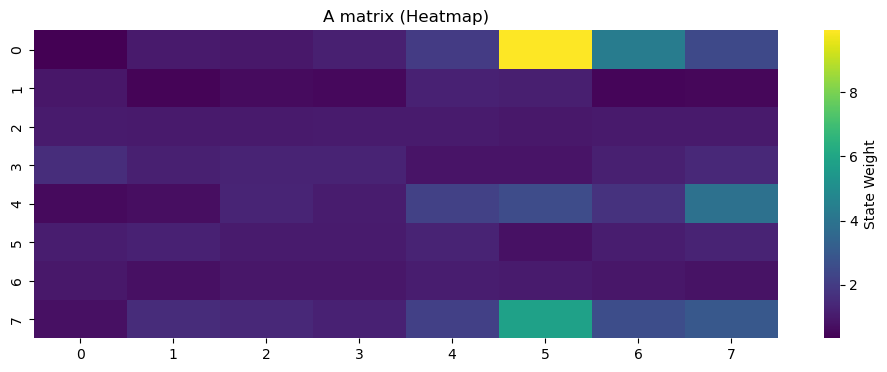

In [22]:
import seaborn as sns
# 2. Heatmap Style Attention Map

plt.figure(figsize=(12, 4))  # Shorter height for heatmap
sns.heatmap(torch.exp(model.mamba.layers[0].mixer.A_log).detach().numpy(),  # Reshape for heatmap
            cmap="viridis",  # Choose a suitable colormap
            xticklabels=True,  # Hide x-axis ticks if many time steps
            cbar_kws={'label': 'State Weight'}) # Add a colorbar with label


plt.title("A matrix (Heatmap)")
plt.show()

In [23]:
from scipy.io import savemat

#RMSBlock1
RMSWeight1 = model.mamba.layers[0].norm.weight.detach().numpy()

#RMSBlock2
RMSWeight2 = model.mamba.norm_f.weight.detach().numpy()

#Input Linear Projection to embedding
LinearInWeight = model.lin1.weight.detach().numpy()
LinearInBias = model.lin1.bias.detach().numpy()

#Expansion Linear Projection
LinearExpansionWeight  = model.mamba.layers[0].mixer.in_proj.weight.detach().numpy()
#No Bias

#Convolutional Layer
ConvWeight = model.mamba.layers[0].mixer.conv1d.weight.detach().numpy()
ConvBias = model.mamba.layers[0].mixer.conv1d.bias.detach().numpy()

#DeltaBC Projection
SelectionProjectionWeight = model.mamba.layers[0].mixer.x_proj.weight.detach().numpy()
#No Bias

#Sampling Time Projection
DeltaTProjectionWeight = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy()
DeltaTProjectionBias = model.mamba.layers[0].mixer.dt_proj.bias.detach().numpy()

##SSM Paramters
A = model.mamba.layers[0].mixer.A_log.detach().numpy()
D = model.mamba.layers[0].mixer.D.detach().numpy()


#Reduction Projection
LinearReductionWeight = model.mamba.layers[0].mixer.out_proj.weight.detach().numpy()
#No bias

# # #Output Projection
# LinearSequenceProjectionWeight = model.lin2.weight.detach().numpy()
# LinearSequenceProjectionBias = model.lin2.bias.detach().numpy()


#Output Projection
LinearOutputWeight = model.MLP.weight.detach().numpy()
LinearOutputBias = model.MLP.bias.detach().numpy()





# savemat(
#     "MambaParameters"+".mat",
#     {'LinearInWeight': LinearInWeight, 'LinearInBias': LinearInBias ,  'LinearExpansionWeight': LinearExpansionWeight,
#       'ConvWeight': ConvWeight, 'ConvBias': ConvBias, 'SelectionProjectionWeight': SelectionProjectionWeight,
#         'DeltaTProjectionWeight': DeltaTProjectionWeight, 'DeltaTProjectionBias': DeltaTProjectionBias, 
#          'A': A, 'D': D, 'LinearReductionWeight': LinearReductionWeight,  'LinearOutputWeight': LinearOutputWeight, 'LinearOutputBias': LinearOutputBias,'RMSWeight1': RMSWeight1 ,'RMSWeight2': RMSWeight2})

# savemat(
#     "MambaParameters"+".mat",
#     {'LinearInWeight': LinearInWeight, 'LinearInBias': LinearInBias ,  'LinearExpansionWeight': LinearExpansionWeight,
#       'ConvWeight': ConvWeight, 'ConvBias': ConvBias, 'SelectionProjectionWeight': SelectionProjectionWeight,
#         'DeltaTProjectionWeight': DeltaTProjectionWeight, 'DeltaTProjectionBias': DeltaTProjectionBias, 
#          'A': A, 'D': D, 'LinearReductionWeight': LinearReductionWeight,'LinearSequenceProjectionWeight': LinearSequenceProjectionWeight,  'LinearSequenceProjectionBias': LinearSequenceProjectionBias,   'LinearReductionWeight':LinearReductionWeight ,  'LinearOutputWeight': LinearOutputWeight, 'LinearOutputBias': LinearOutputBias,'RMSWeight1': RMSWeight1 ,'RMSWeight2': RMSWeight2})


In [24]:
from numpy import linalg as LA

print("Conditioning number of lin1: "+ str(LA.cond(model.lin1.weight.detach().numpy())))
print("Conditioning number of MLP: "+ str(LA.cond(model.MLP.weight.detach().numpy())))
print("Conditioning number of A_log: "+ str(LA.cond(model.mamba.layers[0].mixer.A_log.detach().numpy())))
print("Conditioning number of A: "+ str(LA.cond(A)))
print("Conditioning number of SelectionProjectionWeight: "+ str(LA.cond(SelectionProjectionWeight)))
print("Conditioning number of DeltaTProjectionWeight: "+ str(LA.cond(DeltaTProjectionWeight)))
print("Conditioning number of dt_proj: "+ str(LA.cond(model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy())))
print("Conditioning number of LinearInWeight: "+ str(LA.cond(LinearInWeight)))
print("Conditioning number of LinearExpansionWeight: "+ str(LA.cond(LinearExpansionWeight)))
print("Conditioning number of LinearReductionWeight: "+ str(LA.cond(LinearReductionWeight)))
print("Conditioning number of LinearOutputWeight: "+ str(LA.cond(LinearOutputWeight)))

Conditioning number of lin1: 7.4011984
Conditioning number of MLP: 1.2892005
Conditioning number of A_log: 577.1092
Conditioning number of A: 577.1092
Conditioning number of SelectionProjectionWeight: 10.64038
Conditioning number of DeltaTProjectionWeight: 1.0
Conditioning number of dt_proj: 1.0
Conditioning number of LinearInWeight: 7.4011984
Conditioning number of LinearExpansionWeight: 6.1680636
Conditioning number of LinearReductionWeight: 22.419973
Conditioning number of LinearOutputWeight: 1.2892005


In [17]:
inputs = torch.ones(1,29,1)
model.eval()
model(inputs)

tensor([[0.8813, 0.9535, 1.0127, 1.0541, 1.0871, 1.1140, 1.1142, 1.1096, 1.0969,
         1.1087]], grad_fn=<SqueezeBackward1>)

In [25]:
inputs = torch.ones(1,3,4)
unfold = nn.Unfold(kernel_size=2, padding=1)
x_unfold = unfold(inputs.transpose(0,1))
x_unfold = x_unfold
x_unfold.shape

torch.Size([12, 10])

In [ ]:

batch_size, in_channels, width = inputs.shape
out_channels, _, kernel_size = ConvWeight.shape

# Calculate padding for 'same' padding
padding = (kernel_size - 1) // 2

# Pad the input tensor
padded_input = F.pad(inputs, (padding, padding))

In [21]:
ConvWeight.shape

(4, 1, 2)

In [22]:
(x_unfold*ConvWeight.T+ConvBias).shape

torch.Size([2, 20, 4])

In [27]:
# Create a dummy 1D convolutional layer (replace with your trained layer)
conv_layer = nn.Conv1d(in_channels=4, out_channels=4, kernel_size=2)

with torch.no_grad():
    conv_layer.weight.copy_(torch.tensor(ConvWeight,  dtype=torch.float32))
    conv_layer.bias.copy_(torch.tensor(ConvBias, dtype=torch.float32))

x = torch.tensor(np.ones((1,3,4)), dtype=torch.float32)

conv_layer(x.transpose(1,2))[:,:,:3].transpose(1,2)

tensor([[[ 0.2044, -1.1942, -0.7005, -1.2355],
         [ 0.2044, -1.1942, -0.7005, -1.2355]]], grad_fn=<TransposeBackward0>)

In [ ]:
model.mamba.layers[0].mixer.in_proj.weight.shape

In [29]:
x = torch.ones(1,3,4).transpose(1,2)
x = model.mamba.layers[0].mixer.conv1d(x)
x[:,:,1]

tensor([[ 0.3191, -0.4654,  0.4294,  0.0973]], grad_fn=<SelectBackward0>)

In [28]:
def manual_conv1d_same(input_tensor, weights, bias):
    """
    Manually applies a 1D convolutional layer with 'same' padding.

    Args:
        input_tensor (torch.Tensor): Input tensor of shape (batch_size, in_channels, width).
        weights (torch.Tensor): Convolutional weights of shape (out_channels, in_channels, kernel_size).
        bias (torch.Tensor): Convolutional bias of shape (out_channels,).

    Returns:
        torch.Tensor: Output tensor with the same width as the input.
    """
    batch_size, in_channels, width = input_tensor.shape
    out_channels, _, kernel_size = weights.shape

    # Calculate padding for 'same' padding
    padding = (kernel_size - 1) // 2

    # Pad the input tensor
    padded_input = F.pad(input_tensor, (padding, padding))

    # Initialize the output tensor
    output = torch.zeros(batch_size, out_channels, width)

    # Apply the convolution
    for i in range(width):
        for o in range(out_channels):
            # Extract the relevant slice of the padded input
            slice_input = padded_input[:, :, i:i + kernel_size]

            # Perform the convolution
            conv_result = torch.sum(slice_input * weights[o], dim=[1, 2]) + bias[o]
            output[:, o, i] = conv_result

    return output

# Example usage
input_tensor = torch.ones(1, 4, 3)
kernel_size = 2
in_channels = 4
out_channels = 4

# Initialize weights and bias (for demonstration purposes, simple random values)
weights = torch.randn(out_channels, in_channels, kernel_size)
bias = torch.randn(out_channels)

# Apply the manual convolution
output_manual = manual_conv1d_same(input_tensor, weights, bias)

# Verify with PyTorch's built-in Conv1d
conv1d = nn.Conv1d(in_channels, out_channels, kernel_size, padding='same', bias=True)
conv1d.weight = nn.Parameter(weights)
conv1d.bias = nn.Parameter(bias)
output_pytorch = conv1d(input_tensor)

print("Manual Convolution Output:")
print(output_manual)

print("\nPyTorch Conv1d Output:")
print(output_pytorch)

print("\nDifference between manual and pytorch:")
print(output_manual - output_pytorch)

Manual Convolution Output:
tensor([[[-2.2976, -2.2976, -2.2976],
         [-1.2358, -1.2358, -1.2358],
         [ 0.3182,  0.3182,  0.3182],
         [-1.5958, -1.5958, -1.5958]]])

PyTorch Conv1d Output:
tensor([[[-2.2976, -2.2976, -1.2716],
         [-1.2358, -1.2358,  1.9070],
         [ 0.3182,  0.3182,  1.9551],
         [-1.5958, -1.5958, -0.5676]]], grad_fn=<ConvolutionBackward0>)

Difference between manual and pytorch:
tensor([[[ 0.0000e+00,  0.0000e+00, -1.0260e+00],
         [-1.1921e-07, -1.1921e-07, -3.1428e+00],
         [ 0.0000e+00,  0.0000e+00, -1.6369e+00],
         [ 0.0000e+00,  0.0000e+00, -1.0281e+00]]], grad_fn=<SubBackward0>)


c:\Users\Michiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\conv.py:306: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ..\aten\src\ATen\native\Convolution.cpp:1032.)
  return F.conv1d(input, weight, bias, self.stride,


In [ ]:
from scipy.linalg import toeplitz
x = [0,0,1,1,1,1,1,1,1,1,0,0,0]
x = torch.tensor([float(i) for i in x]).unsqueeze(1).unsqueeze(0)


combined_W = []
for i in range(ConvWeight.shape[0]):
    kernel = ConvWeight[i, 0, :]
    # Create a Toeplitz-like matrix for each kernel.
    first_col = np.concatenate(([kernel[2]], [kernel[3]],[kernel[4]],[kernel[5]], [0], [0], [0], [0]))
    first_row = np.concatenate(([kernel[2]], [kernel[1]],[kernel[0]], np.zeros(10)))
    toeplitz_matrix = toeplitz(first_col, first_row)
    combined_W.append(toeplitz_matrix)

combined_W = np.concatenate(combined_W, axis=0)

In [ ]:
ConvBias

In [ ]:
x*torch.tensor(combined_W)

In [ ]:
combined_W*x

In [ ]:
x = [0,0,1,1,1,1,1,1,1,1,0,0,0]
x = torch.tensor([float(i) for i in x]).unsqueeze(1)

torch.tensor(combined_W).transpose(0,1)*x+ConvBias

In [ ]:
uN= np.array(torch.load("uNMPC.pt"))
u_ini_list = np.array(torch.load("u_ini.pt"))
y_ini_list = np.array(torch.load("y_ini.pt"))

In [ ]:
yN = []

for i in range(230):
    inputs = np.concatenate((u_ini_list[i].T, y_ini_list[i].T, uN[i]))
    inputs = torch.tensor(inputs, dtype=torch.float)
    yN.append(model(inputs.unsqueeze(0)).detach().numpy())

yN = np.array(yN).reshape(230,10)
print(yN.shape)

In [ ]:
#Sampling Time
Ts = 0.1

# Simulation time
time_range =24

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

mu = 1

# Initial state
x1_init = 1
x2_init = 1

x1 = np.zeros(L + 1)
x2 = np.zeros(L + 1)
u = np.zeros(L)
ref = np.zeros(L)

#Choose the reference
f = 0.1  # Frequency in Hz
A = 2
ref =  A*np.sin(2 * np.pi * f * t)

fig, axs = plt.subplots(2)
fig.suptitle("NMPC Casadi")
axs[0].plot(ref, label="$ref$")
axs[0].plot(yN[:,0] , label = "$NMPC$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-5, 5)

axs[1].plot(uN[:,0])
axs[0].set(ylabel="$y$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$u$")
axs[1].grid()
plt.show()
fig.savefig("MambaNMPCInput.png", format='png')

In [ ]:
model(inputs.unsqueeze(0))

In [ ]:
uN[:,0].shape